# Computer Vision


In [ ]:
## 0. Computer Vision library
import torch
from torch import nn

# torchvision
import torchvision
from torchvision import transforms
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

In [ ]:
### DATA SETS
# FASHION MNIST
# training data
train_data = datasets.FashionMNIST(
    root="data", # where to save
    train=True, # train or test
    download=True, # download it?
    transform=ToTensor(), # to what to transfom
    target_transform=None
    )
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None

)

100%|██████████| 26.4M/26.4M [00:10<00:00, 2.50MB/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 199kB/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 5.65MB/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



In [ ]:
len(train_data),len(test_data)

(60000, 10000)

In [ ]:
# See the first training example
image,label = train_data[20]
image.shape,label

(torch.Size([1, 28, 28]), 3)

In [ ]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
image.shape,label

(torch.Size([1, 28, 28]), 0)

In [ ]:
image,label = train_data[0]
print(f"Image shape:{image.shape}")
image.squeeze().shape

Image shape:torch.Size([1, 28, 28])


torch.Size([28, 28])

In [ ]:
import random

(-0.5, 27.5, 27.5, -0.5)

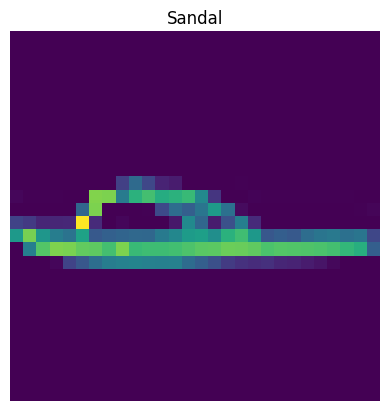

In [ ]:
image,label = train_data[random.randint(1,100)]
plt.imshow(image.squeeze()) # (1,28,28) -> (x,y) -> squeeze() -> (28,28)
plt.title(f"{class_names[label]}")
plt.axis(False)

image shape : torch.Size([1, 28, 28])


(-0.5, 27.5, 27.5, -0.5)

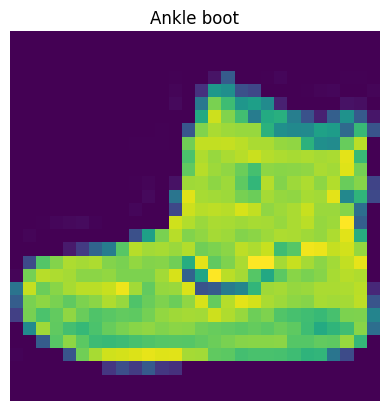

In [ ]:
image,label = train_data[0]
print(f"image shape : {image.shape}")
image

plt.imshow(image.squeeze())
plt.title(class_names[label])
plt.axis(False)

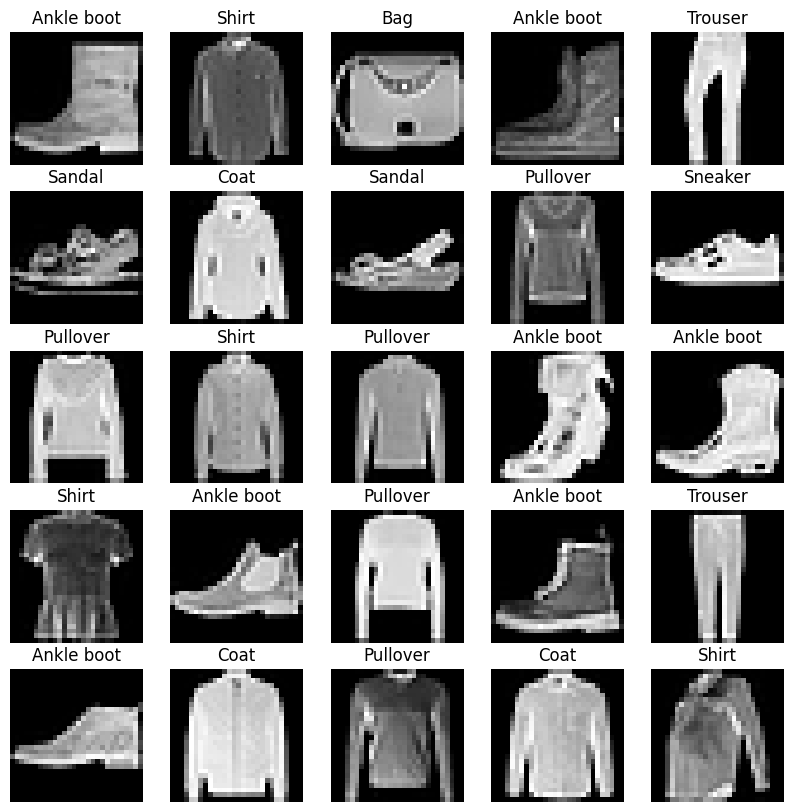

In [ ]:
## Visual multiple
torch.manual_seed(42)
fig = plt.figure(figsize=(10,10))
row,col = 5,5
for i in range(1,row*col+1):
    random_idx = torch.randint(0,len(train_data),size=[1]).item()
    img,label = train_data[random_idx]
    fig.add_subplot(row,col,i)
    plt.imshow(img.squeeze(),cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

In [ ]:
train_data,test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [ ]:
from torch.utils.data import DataLoader
# turn data to tensor
# dataloader turn our dataset into python iterable
BATCH_SIZE = 32
# turn to iterables
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)
train_dataloader,test_dataloader


(<torch.utils.data.dataloader.DataLoader at 0x7fd6a06c4400>,
 <torch.utils.data.dataloader.DataLoader at 0x7fd69ffe9450>)

In [ ]:
len(train_dataloader)

1875

In [ ]:
len(test_dataloader)

313

In [ ]:
# lets check the dataloader created
print(f"Dataloaders :{train_dataloader,test_dataloader}")
print(f"Length of train:{len(train_dataloader)}")
print(f"Length of test:{len(test_dataloader)}")
print(f"Batches of :{BATCH_SIZE}")

Dataloaders :(<torch.utils.data.dataloader.DataLoader object at 0x7fd6a06c4400>, <torch.utils.data.dataloader.DataLoader object at 0x7fd69ffe9450>)
Length of train:1875
Length of test:313
Batches of :32


In [ ]:
n = next(iter(range(0,100)))
list(range(10))


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [ ]:
train_features_batch,train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape,train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [ ]:
t = torch.Tensor([1])
t.item()

1.0

Image size :torch.Size([1, 28, 28])
Label :1, label size: torch.Size([])


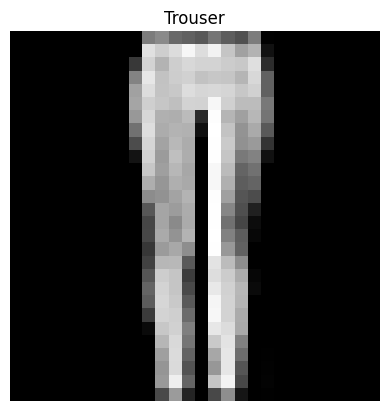

In [ ]:
# VISUAL BATCH
# show a sample
# torch.manual_seed(42)
random_idx = torch.randint(0,len(train_features_batch),size=[1]).item()
img,label = train_features_batch[random_idx],train_labels_batch[random_idx]
plt.imshow(img.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis(False)
print(f"Image size :{img.shape}")
print(f"Label :{label}, label size: {label.shape}")

In [ ]:
# create a flatten layer
flatten_model = nn.Flatten()

x = train_features_batch[0]

# flatten
output = flatten_model(x) # perform forward pass
print(f"Shape before flattening:{x.shape}")
print(f"Shape after flattening:{output.shape}")




Shape before flattening:torch.Size([1, 28, 28])
Shape after flattening:torch.Size([1, 784])


In [ ]:
### MODEL BUILDING - baseline model
# when
class FashionMNISTModelV0(nn.Module):
    def __init__(self,
                 input_shape:int,
                 hidden_units:int,
                 output_shape:int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,out_features=hidden_units),
            nn.Linear(in_features=hidden_units,out_features=output_shape)
        )
    def forward(self,x):
        return self.layer_stack(x)

model0 = FashionMNISTModelV0(input_shape=784,hidden_units=10,output_shape=len(class_names))
print(f"{model0.parameters}")

<bound method Module.parameters of FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)>


In [ ]:
## LOSS
loss_fn = nn.CrossEntropyLoss()

## OPTIMIZER
optimizer = torch.optim.Adam(params=model0.parameters(),lr=0.01)

In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format).
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [ ]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [ ]:
## create a training loop
# loop through training batches, perform training steps the calculate the train loss per batch
# loop through testing batches
# print out
# time out



In [ ]:
%%time
from helper_functions import accuracy_fn

from tqdm.auto import tqdm
epochs = 3
start_time = timer()
for epoch in tqdm(range(epochs)):
    train_loss,acc=0,0
    for batch ,(X,y) in enumerate(train_dataloader):
        model0.train()
        y_preds = model0(X)
        loss = loss_fn(y_preds,y)
        train_loss+=loss
        acc += accuracy_fn(y_true=y,y_pred=y_preds.argmax(dim=1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch%400==0:
            print(f"Looked at: {batch*len(X)}/{len(train_dataloader.dataset)} samples")
    train_loss/=len(train_dataloader)
    acc/=len(train_dataloader)
    # evaluation
    test_loss,test_acc = 0,0
    model0.eval()
    with torch.inference_mode():
        for X_test,y_test in test_dataloader:
            test_preds = model0(X_test)
            test_loss += loss_fn(test_preds,y_test)
            test_acc += accuracy_fn(y_true=y_test,y_pred=test_preds.argmax(dim=1))
        test_loss/=len(test_dataloader)
        test_acc /=len(test_dataloader)
        # print what's happening
        print(f"Train loss:{train_loss:.5f} | acc:{acc}% | Test loss:{test_loss:.5f} | Test acc :{test_acc}%")
end_time = timer()
print(print_train_time(start=start_time,end=end_time))

  0%|          | 0/3 [00:00<?, ?it/s]

Looked at: 0/60000 samples
Looked at: 12800/60000 samples
Looked at: 25600/60000 samples
Looked at: 38400/60000 samples
Looked at: 51200/60000 samples
Train loss:0.56605 | acc:80.27666666666667% | Test loss:0.54001 | Test acc :81.12020766773163%
Looked at: 0/60000 samples
Looked at: 12800/60000 samples
Looked at: 25600/60000 samples
Looked at: 38400/60000 samples
Looked at: 51200/60000 samples
Train loss:0.49356 | acc:82.91166666666666% | Test loss:0.57131 | Test acc :80.97044728434504%
Looked at: 0/60000 samples
Looked at: 12800/60000 samples
Looked at: 25600/60000 samples
Looked at: 38400/60000 samples
Looked at: 51200/60000 samples
Train loss:0.48258 | acc:83.25166666666667% | Test loss:0.51123 | Test acc :82.5179712460064%
Train time on None: 55.289 seconds
55.288899085
CPU times: user 42.7 s, sys: 621 ms, total: 43.4 s
Wall time: 55.4 s


In [ ]:
# make predictions
def eval_model(model:torch.nn.Module,dataloader:torch.utils.data.DataLoader,loss:torch.nn.Module,acc):
    """
    Evaluation of FashionMNISTV0 model

    Parameters:
        model : torch.nn.Module
        dataloader : torch.utils.data.DataLoader
        loss : torch.nn.Module
        acc : from helper functions or any

    Output:
        model: -> name
        loss: by the predictions

    """
    eval_loss = 0
    eval_acc = 0
    model0.eval()
    with torch.inference_mode():
        for X_test,y_test in dataloader:
            prediction = model0(X_test)
            eval_loss += loss_fn(prediction,y_test)
            eval_acc += accuracy_fn(y_test,prediction.argmax(dim=1))
        eval_loss /=len(dataloader)
        eval_acc  /=len(dataloader)
    return {"model_class":model,
            "loss":eval_loss.item(),
            "acc":eval_acc}
eval_model(model=model0,
           dataloader=test_dataloader,
           loss=loss_fn,
           acc=None)



{'model_class': FashionMNISTModelV0(
   (layer_stack): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=784, out_features=10, bias=True)
     (2): Linear(in_features=10, out_features=10, bias=True)
   )
 ),
 'loss': 0.5112314224243164,
 'acc': 82.5179712460064}

In [ ]:
# better model with non-linearity
device = "cuda" if torch.cuda.is_available() else "cpu"
class FashionMNISTModelV1(nn.Module):
    def __init__(self,input,hidden_neuron,output):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input,out_features=hidden_neuron),
            nn.ReLU(),
            nn.Linear(in_features=hidden_neuron,out_features=hidden_neuron),
            nn.ReLU(),
            nn.Linear(in_features=hidden_neuron,out_features=output),
            nn.ReLU(),
        )
    def forward(self,x):
        return self.layer_stack(x)

model_1 = FashionMNISTModelV1(input=784,hidden_neuron=10,output=len(class_names)).to(device)
model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
    (5): Linear(in_features=10, out_features=10, bias=True)
    (6): ReLU()
  )
)

In [ ]:
## loss for non-linearity
loss_fn_1 = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.Adam(params=model_1.parameters(),lr=0.01)

In [ ]:
epochs = 3
for epoch in tqdm(range(epochs)):
    train_loss,train_acc= 0,0
    for batch,(X,y) in enumerate(train_dataloader):
        X = X.to(device)
        y = y.to(device)
        model_1.train()
        y_preds = model_1(X)
        loss = loss_fn_1(y_preds,y)
        train_loss+=loss
        train_acc+= accuracy_fn(y_true=y,y_pred=y_preds.argmax(dim=1))
        optimizer_1.zero_grad()
        loss.backward()
        optimizer_1.step()
        if batch%400==0:
            print(f"Looking at {batch*len(X)}/{len(train_dataloader.dataset)}")
    train_loss/=len(train_dataloader)
    train_acc/=len(train_dataloader)

    model_1.eval()
    with torch.inference_mode():
        test_loss,test_acc = 0,0
        for X_test,y_test in test_dataloader:
            X_test = X_test.to(device)
            y_test = y_test.to(device)
            test_preds = model_1(X_test)
            test_loss += loss_fn_1(test_preds,y_test)
            test_acc += accuracy_fn(y_true=y_test,y_pred=test_preds.argmax(dim=1))
        test_loss /=len(test_dataloader)
        test_acc  /=len(test_dataloader)
        print(f"Train Loss:{loss} | Train Acc :{train_acc:.2f}% | Test Loss :{test_loss} | Test Acc :{test_acc:.2f}%")

  0%|          | 0/3 [00:00<?, ?it/s]

Looking at 0/60000
Looking at 12800/60000
Looking at 25600/60000
Looking at 38400/60000
Looking at 51200/60000
Train Loss:0.6937822103500366 | Train Acc :78.60% | Test Loss :0.6310569643974304 | Test Acc :76.24%
Looking at 0/60000
Looking at 12800/60000
Looking at 25600/60000
Looking at 38400/60000
Looking at 51200/60000
Train Loss:0.7505370378494263 | Train Acc :82.98% | Test Loss :0.5178436636924744 | Test Acc :81.46%
Looking at 0/60000
Looking at 12800/60000
Looking at 25600/60000
Looking at 38400/60000
Looking at 51200/60000
Train Loss:0.3540862798690796 | Train Acc :83.94% | Test Loss :0.4734705686569214 | Test Acc :83.75%


In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
# FUNCTIONISING THE STEP IN TRAINING AND TEST
def train_step(model:torch.nn.Module
               ,loss_fn:torch.nn,
               optimizer:torch.optim):
    model.train()
    train_loss,train_acc = 0,0
    for batch,(X,y) in enumerate(train_dataloader):
        X,y = X.to(device),y.to(device)
        y_preds = model(X)
        loss = loss_fn(y_preds,y)
        train_loss+=loss
        train_acc += accuracy_fn(y,y_preds.argmax(dim=1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 400==0:
            print(f"Looking at {batch * len(X)}/{len(train_dataloader.dataset)}")
    train_loss/=len(train_dataloader)
    train_acc/=len(train_dataloader)
    print(f"Train Loss:{train_loss:.5f} | Train Acc:{train_acc:.2f}%")

def test_step(model:torch.nn.Module,
              loss_fn:torch.nn):
    test_loss,test_acc = 0,0
    model.eval()
    with torch.inference_mode():
        for X_test,y_test in test_dataloader:
            X_test,y_test = X_test.to(device),y_test.to(device)
            y_preds = model(X)
            test_loss += loss_fn(y_preds,y)
            test_acc += accuracy_fn(y,y_preds.argmax(dim=1))
        test_loss/=len(test_dataloader)
        test_acc/=len(test_dataloader)
        print(f"Test loss:{test_loss:.5f} | Test Acc:{test_acc:.2f}% :")

NameError: name 'torch' is not defined

In [ ]:
## Training loop
torch.manual_seed(42)
epochs = 3
for epoch in tqdm(range(epochs)):
    train_step(model=model_1,
               loss_fn=loss_fn,
               optimizer=optimizer_1
               )
    # evaluation
    test_step(
        model=model_1,
        loss_fn=loss_fn,
    )

  0%|          | 0/3 [00:00<?, ?it/s]

Looking at 0/60000
Looking at 12800/60000
Looking at 25600/60000
Looking at 38400/60000
Looking at 51200/60000
Train Loss:0.45328 | Train Acc:84.06%
Test loss:0.37826 | Test Acc:87.50% :
Looking at 0/60000
Looking at 12800/60000
Looking at 25600/60000
Looking at 38400/60000
Looking at 51200/60000
Train Loss:0.44375 | Train Acc:84.36%
Test loss:0.29711 | Test Acc:90.62% :
Looking at 0/60000
Looking at 12800/60000
Looking at 25600/60000
Looking at 38400/60000
Looking at 51200/60000
Train Loss:0.44036 | Train Acc:84.39%
Test loss:0.31929 | Test Acc:87.50% :


In [ ]:


## get model_1 dictionary
def eval_model(
        model:torch.nn.Module
):
    model.eval()
    test_loss,test_acc = 0,0
    with torch.inference_mode():
        for X_test , y_test in test_dataloader:
            X_test,y_test = X_test.to(device),y_test.to(device)
            test_predictions = model(X_test)
            test_loss += loss_fn(test_predictions,y_test)
            test_acc += accuracy_fn(y_test,test_predictions.argmax(dim=1))
        test_loss /= len(test_dataloader)
        test_acc  /= len(test_dataloader)
    return {
        "model":model.__class__.__name__,
        "loss":test_loss.item(),
        "acc":test_acc
    }




In [ ]:
model_1_results = eval_model(model=model_1)
model_1_results

{'model': 'FashionMNISTModelV1',
 'loss': 0.4881870150566101,
 'acc': 82.40814696485623}

In [ ]:
# CNN

In [ ]:
import torch
from torch import nn

In [ ]:
class FashionMNISTModelV2(nn.Module):
    def __init__(self,
                 input_shape:int,
                 hidden_units:int,
                 output_shape:int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )
    def forward(self,x):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x)
        return x

In [ ]:
torch.manual_seed(42)


In [ ]:
model_2 = FashionMNISTModelV2(
    input_shape=1,
    hidden_units=32,
    output_shape=len(class_names),

)


In [ ]:
# next(model_2.parameters())

In [ ]:
torch.manual_seed(42)
# create a batch of images
images = torch.randn(size=(32,3,64,64))
# shapes
test_image = images[0]
images.shape,test_image.shape
#

(torch.Size([32, 3, 64, 64]), torch.Size([3, 64, 64]))

In [ ]:
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=1)
# pass
conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 64, 64])

In [ ]:
max_layer  = nn.MaxPool2d(kernel_size=2)
conv_output.shape, max_layer(conv_output).shape


(torch.Size([10, 64, 64]), torch.Size([10, 32, 32]))

In [ ]:
torch.manual_seed(42)
# create a random tensor with a similar number of dimensions
random_tensor = torch.randn(size=(1,1,2,2))
max_pool = nn.MaxPool2d(kernel_size=1)
max_pool(random_tensor)

tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])

In [ ]:
dummy = torch.randn(size=(1,1,28,28))
model_2(dummy)

tensor([[-0.0460, -0.0056,  0.0364,  0.0179,  0.0010,  0.0062,  0.0652, -0.0130,
          0.0582, -0.1064]], grad_fn=<AddmmBackward0>)

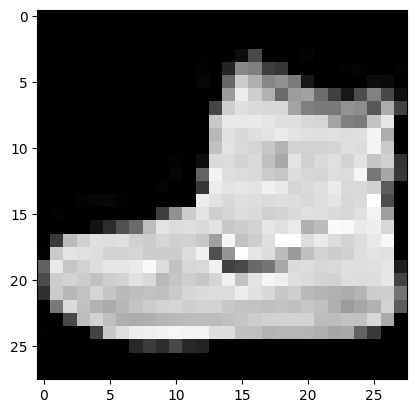

In [ ]:
plt.imshow(image.squeeze(),cmap="gray")

In [ ]:
image.shape

torch.Size([1, 28, 28])

In [ ]:
# torch.manual_seed(42)
# for i in range(20):
#     img,label = train_data[i]
#     # print(img.shape)
#     # plt.figure(figsize=(3,3))
#     # plt.imshow(img.squeeze(),cmap="gray")
#     # plt.title(class_names[label])
#     pred = model_2(img.unsqueeze(dim=0))
#     print(f"Predicted By Model: {pred}")
#     print(f"Predicted By Model: {class_names[pred.argmax()]}")
#     print(f"Actual: {class_names[label]}\n\n")


In [ ]:
flat= nn.Flatten()
check = torch.randn(size=(1,1,28,28))
flat(check).shape
# random_tensor.shape,flat(random_tensor).shape

torch.Size([1, 784])

plt.plot(pred.detach().numpy()[0])

## TIME FOR TRAINING
# loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.paramters,lr=0.01)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(),lr=0.01)

In [ ]:
# Training Loop
epochs = 3
for epoch in tqdm(range(epochs)):
    train_step(model=model_2.to(device),
               loss_fn=loss_fn,
               optimizer=optimizer)
    test_step(model=model_2,
              loss_fn=loss_fn)


  0%|          | 0/3 [00:00<?, ?it/s]

Looking at 0/60000
Looking at 12800/60000
Looking at 25600/60000
Looking at 38400/60000
Looking at 51200/60000
Train Loss:0.45219 | Train Acc:83.68%
Test loss:0.41032 | Test Acc:81.25% :
Looking at 0/60000
Looking at 12800/60000
Looking at 25600/60000
Looking at 38400/60000
Looking at 51200/60000
Train Loss:0.36064 | Train Acc:86.88%
Test loss:0.31158 | Test Acc:81.25% :
Looking at 0/60000
Looking at 12800/60000
Looking at 25600/60000
Looking at 38400/60000
Looking at 51200/60000
Train Loss:0.34562 | Train Acc:87.38%
Test loss:0.32559 | Test Acc:87.50% :


In [ ]:

# for i in range(20,200):
#     image,label = train_data[i]
#     predic = model_2(image.unsqueeze(dim=0))
#     if class_names[label] != class_names[predic.argmax()]:
#         plt.figure(figsize=(3,3))
#         plt.imshow(image.squeeze(),cmap="gray")
#         plt.title(f"Actual: {class_names[label]} | Predicted: {class_names[predic.argmax()]}")

In [ ]:
model_2_results = eval_model(model=model_2)
model_2_results

{'model': 'FashionMNISTModelV2',
 'loss': 0.3657684028148651,
 'acc': 86.63138977635782}

In [ ]:
# # evaluation / testing
# model_2.eval()
# with torch.inference_mode():
#     test_loss,test_acc = 0,0
#     for X_test,y_test in test_dataloader:
#         X_test,y_test = X_test.to(device),y_test.to(device)
#         for i in range(len(X_test)):
#             image = X_test[i]
#             label = y_test[i]
#             pred = model_2(image.unsqueeze(dim=0))
#             print(f"Actual: {class_names[label]} | Predicted :{class_names[pred.argmax(dim=1)]} ")
#             # test_loss += loss_fn(pred,label)
#             # test_acc += accuracy_fn(y_true=label,y_pred=pred.argmax(dim=1))
#         test_preds = model_2(X_test)
#         test_loss += loss_fn(test_preds,y_test)
#         test_acc += accuracy_fn(y_test,test_preds.argmax(dim=1))
#         test_loss /= len(test_dataloader)
#     test_acc /= len(test_dataloader)
#     print(f"Test loss:{test_loss:.5f} Test Acc:{test_acc:.2f}% :")

# evaluation or testing on a random
## make and evaluate random predictions with best the model


In [ ]:
def make_predictions(
        model:torch.nn.Module,
        data:list,
        device:torch.device = device
):
    preds_probs = []
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample,dim=0).to(device)
            # forward pass
            pred_logit = model(sample)
            # prediction probablity
            pred_prob = torch.softmax(pred_logit.squeeze(),dim=0)
            # get data off the gpu
            preds_probs.append(pred_prob.cpu())

    return torch.stack(preds_probs)




In [ ]:
# value = make_predictions(
#     model=model_2,
#     data=test_data,
#     device=device
# )
# value

In [ ]:
import random
# random.seed(42)
test_samples = []
test_labels = []
for sample,label in random.sample(list(test_data),k=9):
    test_samples.append(sample)
    test_labels.append(label)
test_samples[0].shape


torch.Size([1, 28, 28])

Text(0.5, 1.0, 'T-shirt/top')

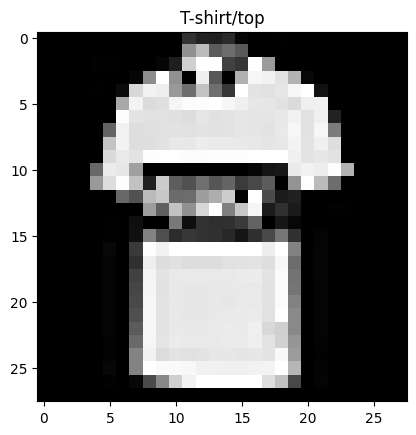

In [ ]:
plt.imshow(test_samples[0].squeeze(),cmap="gray")
plt.title(class_names[test_labels[0]])

In [ ]:
# make predictions
pred_proba = make_predictions(model=model_2,
                         data=test_samples)
# view first two
pred_proba[:2]

tensor([[6.8872e-01, 1.9163e-06, 5.7473e-04, 8.3866e-02, 8.2945e-04, 1.5579e-10,
         1.0329e-01, 1.7490e-08, 1.2272e-01, 1.1817e-09],
        [1.7022e-03, 1.0603e-02, 4.6043e-04, 9.8530e-01, 6.2309e-04, 9.6486e-05,
         4.6170e-04, 1.6595e-05, 7.3499e-04, 4.1999e-06]])

In [ ]:
# convert prediction probablities to labels
pred_classes = pred_proba.argmax(dim=1)
pred_classes

tensor([0, 3, 5, 0, 4, 9, 3, 9, 5])

In [ ]:

def refresh_samples():
    test_samples = []
    test_labels = []
    for sample,label in random.sample(list(test_data),k=9):
        test_samples.append(sample)
        test_labels.append(label)
    pred_proba = make_predictions(model=model_2,
                                  data=test_samples)
    pred_classes = pred_proba.argmax(dim=1)
    return test_samples,test_labels,pred_classes

In [ ]:
test_labels


[0, 3, 5, 0, 6, 9, 3, 9, 5]

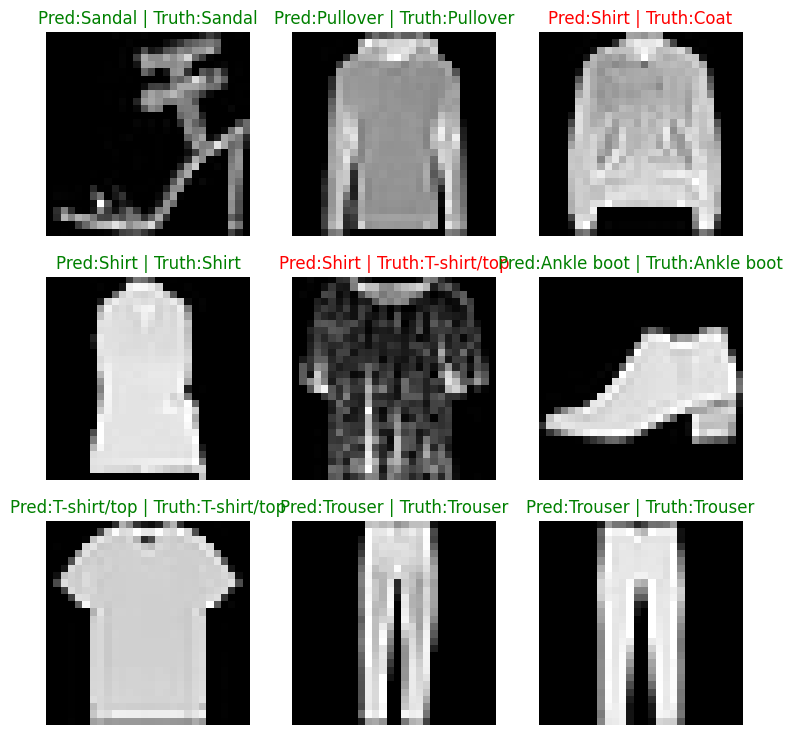

In [ ]:
# plot and compare
test_samples,test_labels,pred_classes = refresh_samples()
plt.figure(figsize=(9,9))
nrows,ncols = 3,3
for i,sample in enumerate(test_samples):
    plt.subplot(nrows,ncols,i+1)
    plt.imshow(sample.squeeze(),cmap="gray")
    pred_label = class_names[pred_classes[i]]
    truth_label = class_names[test_labels[i]]
    title_text = f"Pred:{pred_label} | Truth:{truth_label}"
    # check
    if pred_label == truth_label:
        plt.title(title_text,color="green")
    else:
        plt.title(title_text,color="red")
    plt.axis(False)

In [ ]:
## confusion

In [ ]:
# make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
    for X,y in tqdm(test_dataloader,desc="Making predictions"):
        X,y = X.to(device),y.to(device)
        y_logit =model_2(X)
        # turn
        y_pred = torch.softmax(y_logit.squeeze(),dim=0).argmax(dim=1)
        # put on cpu for evaluation
        y_preds.append(y_pred.cpu())

# print(y_preds)
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1,  ..., 0, 1, 8])

In [ ]:
!pip install torchmetrics
try:
    import torchmetrics,mlxtend
    print(f"mlxtend version :{mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19,"mlxtend version should be 0.19 or higher"
except:
    !pip install -q torchmetrics -U mlxtend
    import torchmetrics,mlxtend
    print(f"mlxtend version :{mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19,"mlxtend version should be 0.19 or higher"

mlxtend version :0.23.1


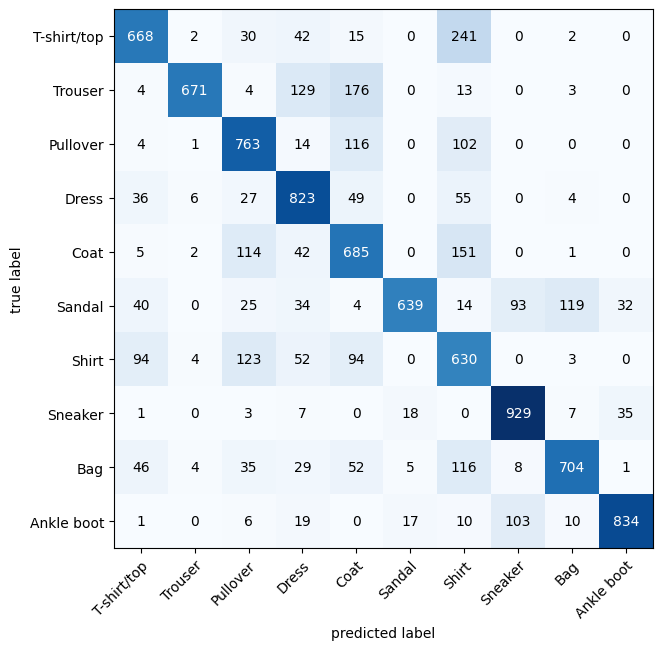

In [ ]:
import mlxtend
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(task="multiclass",num_classes=len(class_names))
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

fig,ax = plot_confusion_matrix(conf_mat=confmat_tensor.numpy(),
                               class_names= class_names,
                               figsize=(10,7))

# Save the model

In [ ]:
# save the model
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)
MODEL_NAME = "fashion_mnist_model_v2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
torch.save(obj=model_2.state_dict(),f=MODEL_SAVE_PATH)

In [ ]:
# LOAD
model_2_load = FashionMNISTModelV2(
    input_shape=1,
    hidden_units=32,
    output_shape=len(class_names)
)
model_2_load.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
model_new = FashionMNISTModelV2(
    input_shape=1,
    hidden_units=32,
    output_shape=len(class_names)
).to(device)
loaded_model_results = eval_model(
    model=model_new
)
loaded_model_results

{'model': 'FashionMNISTModelV2',
 'loss': 2.3025124073028564,
 'acc': 7.967252396166134}

In [ ]:
torch.manual_seed(42)
model_2_load.to(device)
loaded_model_results = eval_model(
    model=model_2_load,
)
loaded_model_results

{'model': 'FashionMNISTModelV2',
 'loss': 0.3657684028148651,
 'acc': 86.63138977635782}

In [ ]:
torch.manual_seed(42)

model_2.to(device)
prev_model_results = eval_model(
    model=model_2,
)
prev_model_results==loaded_model_results

True